# Regularización: Ridge, Lasso y Elastic Net

**Unidad 9 · Machine Learning · Notebook 1 de 6**

Primer notebook del bloque **supervisado**. La variable a explicar es cuantitativa, así
que estamos en la rama de **regresión** del esquema que vimos en `9.0`.

## De la unidad 5 a este notebook

En la unidad 5 estimamos una regresión lineal múltiple y leímos sus coeficientes. El
modelo era

$$ y = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k + \varepsilon $$

y elegíamos los $\beta$ que minimizan la suma de los residuos al cuadrado.

Acá cambiamos **una sola cosa**: le agregamos a esa función objetivo un término que
penaliza el tamaño de los coeficientes. Todo lo demás —la ecuación, la interpretación de
$\beta_j$, los datos— queda igual.

Ese cambio mínimo resuelve un problema que la unidad 5 dejó abierto: **qué hacer cuando
los predictores se mueven juntos**. Y abre la puerta a un escenario que con mínimos
cuadrados es directamente imposible: tener más variables que observaciones.

## El recorrido

1. **El problema.** Ajustamos un OLS común y vemos cómo la colinealidad produce
   coeficientes gigantes, de signo absurdo y que se cancelan entre sí.
2. **La respuesta manual.** Sacar variables a mano. Funciona, pero cuesta.
3. **La respuesta penalizada.** Ridge, Lasso y Elastic Net: qué penalizan, por qué una
   selecciona variables y la otra no, y cómo se elige cuánto penalizar.
4. **Cuando $p \approx n$.** El escenario donde la regularización deja de ser un ajuste
   fino y pasa a ser la única opción.
5. **Cierre aplicado.** Los residuos como herramienta sustantiva: qué países son mucho
   menos transparentes de lo que su estructura predice, y por qué eso es una pregunta de
   investigación y no un error del modelo.

## Requisitos

Este notebook usa solo librerías del ecosistema científico estándar de Python. La celda
siguiente **no instala nada**: lista lo que hace falta y verifica qué tenés en tu entorno.
Si algo falta, instalalo vos y reiniciá el kernel.

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2


  matplotlib       3.9.2


  seaborn          0.13.2


  sklearn          1.9.0
  statsmodels      0.14.2

Todo listo.


## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  RidgeCV, LassoCV, ElasticNetCV)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

SEED = 42
np.random.seed(SEED)

PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## Los datos: Quality of Government

Usamos el corte transversal de **QOG** (*Quality of Government*, Universidad de
Gotemburgo), que reúne en una sola tabla indicadores de 194 países provenientes de
decenas de fuentes: V-Dem, Banco Mundial, Freedom House, Transparency International,
World Justice Project.

Una fila por país, 320 columnas.

In [3]:
qog = pd.read_stata("../../dataset/QOG/qog_bas_cs_jan26.dta", convert_categoricals=False)
print("filas (países):", qog.shape[0])
print("columnas:", qog.shape[1])
qog[["cname", "ti_cpi", "vdem_libdem", "wdi_gdpcapcon2015"]].head()

filas (países): 194
columnas: 320


,cname,ti_cpi,vdem_libdem,wdi_gdpcapcon2015
0,Afghanistan,24.0,0.012,377.665627
1,Albania,36.0,0.433,5867.650962
2,Algeria,33.0,0.115,4544.466881
3,Andorra,NaN,NaN,39780.415299
4,Angola,33.0,0.154,2860.902519


## La pregunta

**¿Qué explica que un país sea percibido como más o menos corrupto?**

La variable a explicar es `ti_cpi`, el *Corruption Perceptions Index* de Transparency
International. Va de 0 a 100 y **más alto significa menos corrupción percibida**: Dinamarca
y Nueva Zelanda están arriba de 85, Sudán del Sur y Somalia abajo de 15.

Como predictores tomamos diez indicadores que la literatura de política comparada asocia
con la corrupción:

| Variable | Fuente | Qué mide |
|---|---|---|
| `vdem_polyarchy` | V-Dem | democracia electoral (0-1) |
| `vdem_libdem` | V-Dem | democracia liberal (0-1) |
| `vdem_partipdem` | V-Dem | democracia participativa (0-1) |
| `undp_hdi` | PNUD | desarrollo humano (0-1) |
| `wdi_gdpcapcon2015` | Banco Mundial | PBI per cápita (US$ 2015) |
| `rsf_pfi` | RSF | libertad de prensa (0-100) |
| `ef_ef` | Fraser | libertad económica (0-10) |
| `wdi_popurb` | Banco Mundial | población urbana (%) |
| `wdi_lifexp` | Banco Mundial | esperanza de vida (años) |
| `wdi_internet` | Banco Mundial | uso de internet (% población) |

In [4]:
PREDICTORES = ["vdem_polyarchy", "vdem_libdem", "vdem_partipdem", "undp_hdi",
               "wdi_gdpcapcon2015", "rsf_pfi", "ef_ef", "wdi_popurb",
               "wdi_lifexp", "wdi_internet"]
OBJETIVO = "ti_cpi"

datos = qog[["cname"] + PREDICTORES + [OBJETIVO]].dropna().reset_index(drop=True)
print(f"casos completos: {len(datos)} de {len(qog)} países")
datos[PREDICTORES + [OBJETIVO]].describe().T.round(2)

casos completos: 152 de 194 países


,count,mean,std,min,25%,50%,75%,max
vdem_polyarchy,152.0,0.51,0.26,0.02,0.28,0.51,0.74,0.92
vdem_libdem,152.0,0.39,0.26,0.01,0.15,0.36,0.63,0.89
vdem_partipdem,152.0,0.33,0.20,0.01,0.16,0.31,0.49,0.80
undp_hdi,152.0,0.74,0.16,0.38,0.61,0.76,0.88,0.97
wdi_gdpcapcon2015,152.0,14792.63,20754.83,263.59,1790.15,5827.26,17722.11,107467.19
rsf_pfi,152.0,58.76,16.36,23.22,46.40,58.72,70.57,92.65
ef_ef,152.0,3.29,2.47,0.50,1.27,2.58,4.54,14.98
wdi_popurb,152.0,61.61,21.25,14.74,44.52,63.56,78.45,100.00
wdi_lifexp,152.0,72.35,8.50,18.82,66.89,74.13,77.93,84.00
wdi_internet,152.0,68.09,26.56,7.51,47.85,78.49,88.95,100.00


### Quién se quedó afuera, y por qué importa

Perdimos 42 países. No es un detalle técnico: `dropna()` hace **eliminación por lista**
(*listwise deletion*), o sea que descarta un país entero si le falta **un solo** valor entre
las once columnas. Conviene mirar siempre a quién sacó.

In [5]:
cobertura = qog[PREDICTORES + [OBJETIVO]].notna().sum().sort_values()
print("Cobertura de cada variable (sobre 194 países):")
print(cobertura.to_string())

excluidos = set(qog["cname"]) - set(datos["cname"])
print(f"\nPaíses excluidos: {len(excluidos)}")

# ¿A cuántos los saca UNA sola variable faltante?
faltantes_por_pais = qog.set_index("cname")[PREDICTORES + [OBJETIVO]].isna().sum(axis=1)
por_una = faltantes_por_pais[(faltantes_por_pais == 1)].index
print(f"De ellos, {len(por_una)} quedan afuera por UNA única variable faltante.\n")

for pais in ["Uruguay", "Venezuela (Bolivarian Republic of)", "Taiwan"]:
    if pais in faltantes_por_pais.index:
        fila = qog[qog["cname"] == pais]
        vacias = [c for c in PREDICTORES + [OBJETIVO] if fila[c].isna().all()]
        print(f"  {pais:38s} le falta: {vacias if vacias else '(nada)'}")

Cobertura de cada variable (sobre 194 países):
ef_ef                170
vdem_polyarchy       172
vdem_libdem          172
vdem_partipdem       172
rsf_pfi              173
ti_cpi               178
wdi_gdpcapcon2015    187
wdi_internet         188
undp_hdi             190
wdi_popurb           192
wdi_lifexp           192

Países excluidos: 42
De ellos, 17 quedan afuera por UNA única variable faltante.

  Uruguay                                le falta: ['ef_ef']
  Venezuela (Bolivarian Republic of)     le falta: ['wdi_internet']


**Uruguay queda fuera del análisis porque le falta un único dato**: `ef_ef`, el índice de
libertad económica del Fraser Institute. Tiene los otros diez valores, incluido el CPI. En
un estudio sobre corrupción en América Latina, perder Uruguay —el país mejor rankeado de la
región— por un indicador secundario es un problema sustantivo grave, y `dropna()` lo hizo en
silencio.

Dos consecuencias prácticas:

1. **La muestra no es aleatoria.** `ef_ef` y los índices de V-Dem son los de menor
   cobertura, y faltan sistemáticamente en países chicos o con menos infraestructura
   estadística. El modelo se estima sobre los países mejor documentados del mundo.
2. **Imputar es una alternativa real**, no una trampa — siempre que se haga dentro del
   pipeline de validación, como haremos más adelante en este mismo notebook.

Y un detalle operativo que arruina más análisis de los que se admite: QOG llama a los
países `Bolivia (Plurinational State of)` y `Dominican Republic (the)`. Filtrar por
`"Bolivia"` no devuelve nada. Siempre hay que verificar los nombres contra los datos, no
contra la intuición.

## Antes de modelar: el predictor que es el objetivo con otro nombre

QOG trae 320 columnas. La tentación es tirarlas todas al modelo y ver qué sale. Antes de
eso, un ejercicio obligatorio: revisar si alguna variable **es** la variable a explicar
disfrazada.

In [6]:
# Correlación de cada indicador de gobernanza con el CPI
sospechosos = ["wbgi_cce", "wbgi_rle", "wbgi_gee", "wbgi_pve", "icrg_qog", "vdem_corr"]
for v in sospechosos:
    sub = qog[[v, OBJETIVO]].dropna()
    print(f"{v:12s}  r = {sub[v].corr(sub[OBJETIVO]):+.3f}   (n = {len(sub)})")

wbgi_cce      r = +0.992   (n = 177)
wbgi_rle      r = +0.956   (n = 177)
wbgi_gee      r = +0.922   (n = 177)
wbgi_pve      r = +0.733   (n = 177)
icrg_qog      r = +0.913   (n = 139)
vdem_corr     r = -0.909   (n = 172)


`wbgi_cce` —el *Control of Corruption* del Banco Mundial— correlaciona **0.992** con el
CPI. Eso no es un hallazgo: el indicador del Banco Mundial se **construye agregando
fuentes**, y una de esas fuentes es el propio CPI de Transparency International.

Si lo usáramos como predictor obtendríamos un $R^2$ de 0.98 y no habríamos explicado
nada. Es un caso de **fuga de información** (*leakage*): el predictor contiene al
objetivo. Y es el más difícil de detectar, porque no hay ningún error de código — solo
hace falta conocer cómo se construyó cada variable.

Por eso a lo largo de todo el notebook excluimos las familias `wbgi_*`, `icrg_*` y el
resto de `ti_*`. Un $R^2$ sospechosamente alto casi siempre es leakage antes que un
modelo brillante.

## Correlaciones entre predictores

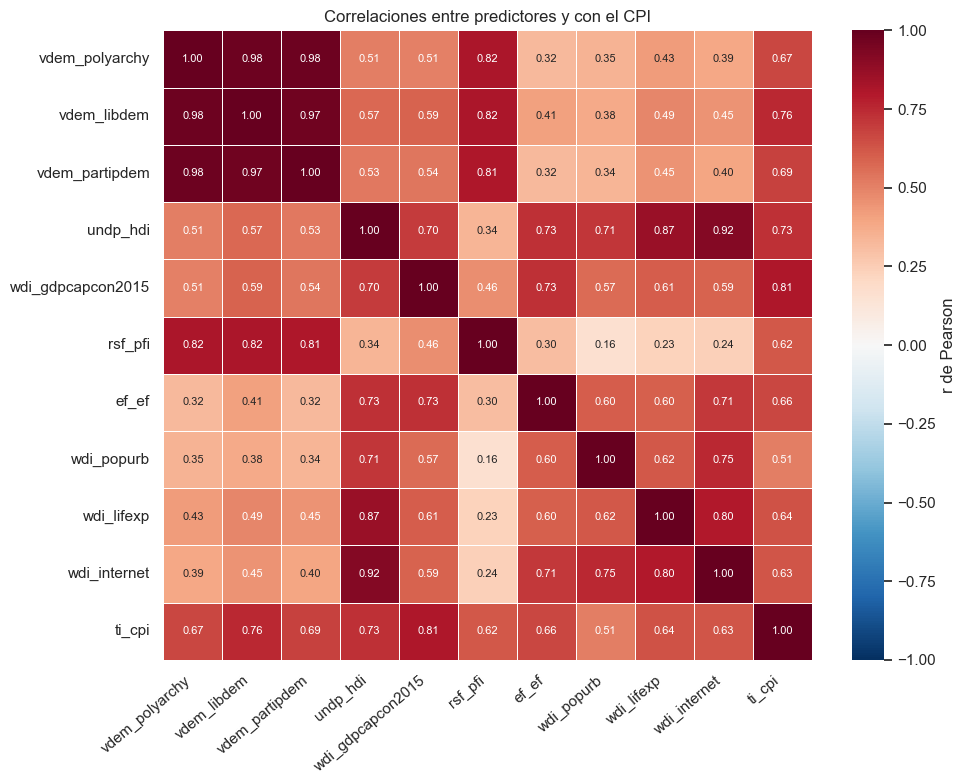

In [7]:
corr = datos[PREDICTORES + [OBJETIVO]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 8}, cbar_kws={"label": "r de Pearson"}, ax=ax)
ax.set_title("Correlaciones entre predictores y con el CPI", fontsize=12)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# Los pares problemáticos, en forma de lista
c = datos[PREDICTORES].corr()
pares = [(PREDICTORES[i], PREDICTORES[j], c.iloc[i, j])
         for i in range(len(PREDICTORES)) for j in range(i + 1, len(PREDICTORES))
         if abs(c.iloc[i, j]) > 0.80]
print("Pares de predictores con |r| > 0.80:\n")
for a, b, r in sorted(pares, key=lambda t: -abs(t[2])):
    print(f"  {a:20s} {b:20s} r = {r:+.3f}")

Pares de predictores con |r| > 0.80:

  vdem_polyarchy       vdem_partipdem       r = +0.979
  vdem_polyarchy       vdem_libdem          r = +0.977
  vdem_libdem          vdem_partipdem       r = +0.972
  undp_hdi             wdi_internet         r = +0.919
  undp_hdi             wdi_lifexp           r = +0.866
  vdem_libdem          rsf_pfi              r = +0.815
  vdem_polyarchy       rsf_pfi              r = +0.815
  vdem_partipdem       rsf_pfi              r = +0.807
  wdi_lifexp           wdi_internet         r = +0.803


Se ven **dos bloques**.

El primero son los tres índices de V-Dem —`polyarchy`, `libdem`, `partipdem`— que
correlacionan entre sí **entre 0.97 y 0.98**, más libertad de prensa pegada a los tres en
0.81. No es casualidad: los tres índices de V-Dem se construyen sobre el mismo núcleo de
indicadores de democracia electoral y después le agregan componentes distintos. Miden
variantes de lo mismo.

El segundo bloque es desarrollo: `undp_hdi` con `wdi_internet` en 0.92 y con `wdi_lifexp`
en 0.87. Otra vez con razón — la esperanza de vida **es uno de los tres componentes** con
los que se calcula el IDH.

Esto es **colinealidad**, y condiciona todo lo que sigue.

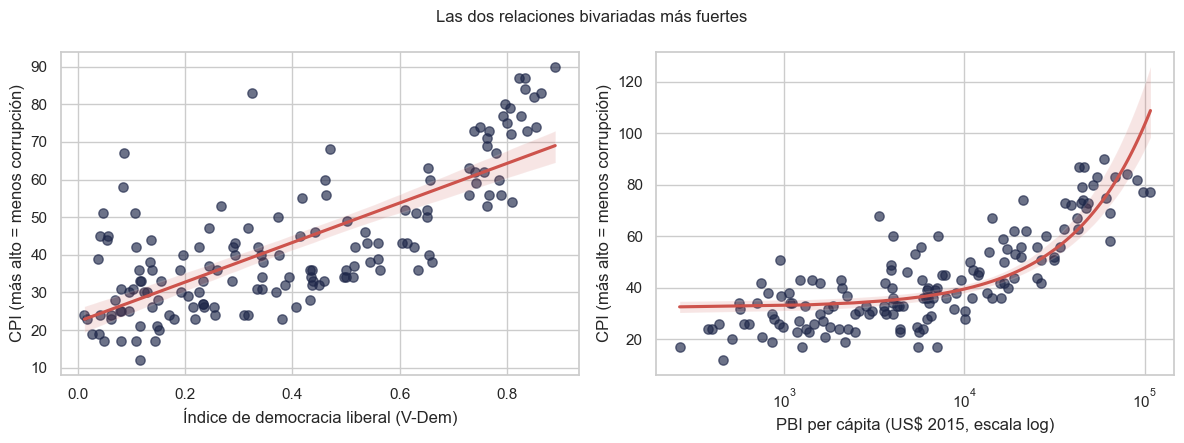

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, v, etiqueta in zip(axes, ["vdem_libdem", "wdi_gdpcapcon2015"],
                           ["Índice de democracia liberal (V-Dem)", "PBI per cápita (US$ 2015)"]):
    sns.regplot(x=datos[v], y=datos[OBJETIVO], ax=ax,
                scatter_kws={"s": 45, "alpha": 0.65, "color": PALETA[4]},
                line_kws={"color": PALETA[2]})
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("CPI (más alto = menos corrupción)")
axes[1].set_xscale("log")
axes[1].set_xlabel("PBI per cápita (US$ 2015, escala log)")
fig.suptitle("Las dos relaciones bivariadas más fuertes", fontsize=12)
plt.tight_layout()
plt.show()

## Modelo 1: mínimos cuadrados ordinarios

> **Qué estima.** El modelo es
> $$ y = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k + \varepsilon $$
> y se eligen los $\beta$ que minimizan la suma de los residuos al cuadrado. La solución
> cerrada es $\hat{\beta} = (X'X)^{-1}X'y$.
>
> **Cómo se lee un coeficiente.** $\beta_j$ es el cambio esperado en el CPI ante un
> aumento de una unidad en $x_j$, **manteniendo constantes las demás variables del
> modelo**. Esa cláusula es la que le da valor interpretativo, y también la primera que se
> rompe.
>
> **Cuándo conviene.** Cuando el objetivo es explicar y no solo predecir. Es el modelo más
> interpretable disponible y el punto de partida obligado.
>
> **Su límite acá.** Cuando los predictores se mueven juntos, la matriz $X'X$ queda mal
> condicionada y su inversa amplifica el ruido. La varianza de los $\hat{\beta}$ se
> dispara: los coeficientes individuales se vuelven poco confiables y pueden cambiar mucho
> ante variaciones menores en los datos, aunque el ajuste global siga siendo bueno.

In [10]:
X = sm.add_constant(datos[PREDICTORES])
y = datos[OBJETIVO]

ols = sm.OLS(y, X).fit()
print(ols.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                 ti_cpi   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     66.93
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.60e-48
Time:                        12:48:48   Log-Likelihood:                -523.61
No. Observations:                 152   AIC:                             1069.
Df Residuals:                     141   BIC:                             1102.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         


In [11]:
tabla_ols = pd.DataFrame({
    "coeficiente": ols.params,
    "error_est": ols.bse,
    "t": ols.tvalues,
    "p_valor": ols.pvalues,
}).round(4)
tabla_ols

,coeficiente,error_est,t,p_valor
const,4.3584,9.8200,0.4438,0.6578
vdem_polyarchy,-49.0942,15.9726,-3.0736,0.0025
vdem_libdem,77.2247,14.6490,5.2717,0.0000
vdem_partipdem,-13.8075,17.8811,-0.7722,0.4413
undp_hdi,18.8302,14.4465,1.3034,0.1945
wdi_gdpcapcon2015,0.0003,0.0001,5.0792,0.0000
rsf_pfi,0.1832,0.0754,2.4307,0.0163
ef_ef,0.3144,0.4702,0.6686,0.5048
wdi_popurb,-0.0175,0.0493,-0.3561,0.7223
wdi_lifexp,0.1066,0.1553,0.6863,0.4937


### La firma de la colinealidad

El modelo explica el **82.6%** de la variación del CPI. Buen ajuste global. Pero mirá los
dos primeros coeficientes:

- `vdem_polyarchy` = **−49.1** (significativo, p = 0.002)
- `vdem_libdem` = **+77.2** (significativo, p < 0.001)

El primero dice que **más democracia electoral implica más corrupción**, y con un efecto
enorme: pasar de 0 a 1 en el índice bajaría el CPI 49 puntos, la mitad de la escala. Es un
disparate sustantivo. El segundo dice lo contrario con un efecto todavía mayor.

Los dos índices correlacionan 0.977. El modelo no puede distinguir su aporte, así que
asigna un coeficiente gigantesco positivo a uno y otro gigantesco negativo al otro: la
suma de los dos efectos reproduce bien los datos, pero **cada coeficiente por separado no
significa nada**. Es la manifestación más nítida de la colinealidad, y bastante peor que
el caso habitual de libro —"ningún coeficiente resulta significativo"— porque acá los
coeficientes absurdos **sí** son significativos.

Cinco de los diez predictores no llegan a significancia al 5%, incluido el IDH, que
bivariadamente correlaciona 0.72 con el CPI.

## El VIF: cuantificar la colinealidad

Para la variable $j$, el **factor de inflación de la varianza** es

$$ \text{VIF}_j = \frac{1}{1 - R_j^2} $$

donde $R_j^2$ es el $R^2$ de regresar $x_j$ contra **todos los demás predictores**. Indica
por cuánto se multiplica la varianza de $\hat\beta_j$ respecto de un escenario sin
colinealidad. Si $x_j$ es independiente del resto, $R_j^2 = 0$ y el VIF vale 1.

Por convención: arriba de 5 conviene mirar, arriba de 10 es problemático.

Se calcula **con el intercepto incluido** en la matriz. Omitirlo infla artificialmente
todos los valores.

In [12]:
def calcular_vif(df_pred):
    Xv = sm.add_constant(df_pred)
    vif = pd.Series(
        [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
        index=Xv.columns, name="VIF"
    ).drop("const")
    return vif.sort_values(ascending=False)

vif_completo = calcular_vif(datos[PREDICTORES])
vif_completo.round(2).to_frame()

,VIF
vdem_polyarchy,40.88
vdem_libdem,36.01
vdem_partipdem,29.91
undp_hdi,12.37
wdi_internet,8.64
wdi_lifexp,4.25
rsf_pfi,3.71
wdi_gdpcapcon2015,3.43
ef_ef,3.29
wdi_popurb,2.67


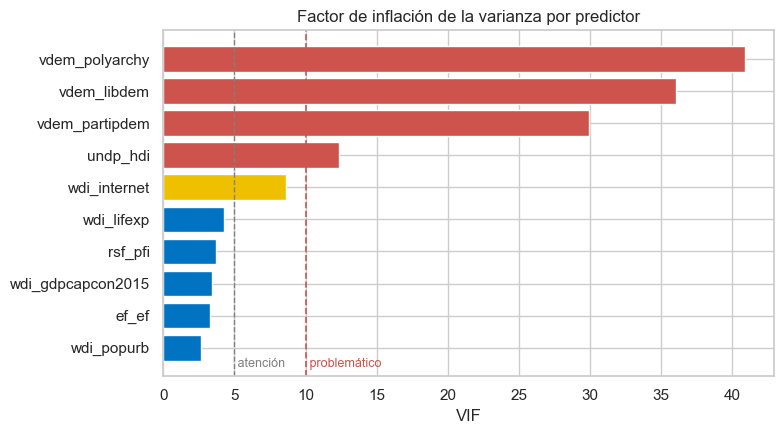

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colores = [PALETA[2] if v > 10 else (PALETA[1] if v > 5 else PALETA[0]) for v in vif_completo]
ax.barh(vif_completo.index[::-1], vif_completo.values[::-1], color=colores[::-1])
ax.axvline(5, color="gray", ls="--", lw=1)
ax.axvline(10, color=PALETA[2], ls="--", lw=1.2)
ax.text(5, -0.6, " atención", color="gray", fontsize=9)
ax.text(10, -0.6, " problemático", color=PALETA[2], fontsize=9)
ax.set_xlabel("VIF")
ax.set_title("Factor de inflación de la varianza por predictor")
plt.tight_layout()
plt.show()

Los tres índices de V-Dem tienen VIF de **41, 36 y 30**: la varianza de sus coeficientes
está inflada entre 30 y 41 veces respecto de un escenario sin colinealidad. Eso es
exactamente lo que vimos en la tabla —errores estándar de 16 y 15 sobre coeficientes que
deberían ser chicos—. El IDH le sigue con 12.4 y el uso de internet con 8.6.

Los seis restantes están por debajo de 5. El problema está localizado en los dos bloques
que ya había marcado la matriz de correlaciones.

## Diagnóstico de los residuos

Antes de seguir, chequear los supuestos. Los cuatro paneles clásicos:

- **Residuos vs. ajustados**: no debería haber patrón ni forma de embudo (linealidad y
  homocedasticidad).
- **Q-Q normal**: los puntos deberían seguir la diagonal (normalidad de los errores).
- **Escala-ubicación**: la raíz de los residuos estandarizados absolutos debería ser plana
  (varianza constante).
- **Residuos vs. leverage**: marca observaciones con influencia desproporcionada; la
  distancia de Cook alta señala casos que por sí solos mueven los coeficientes.

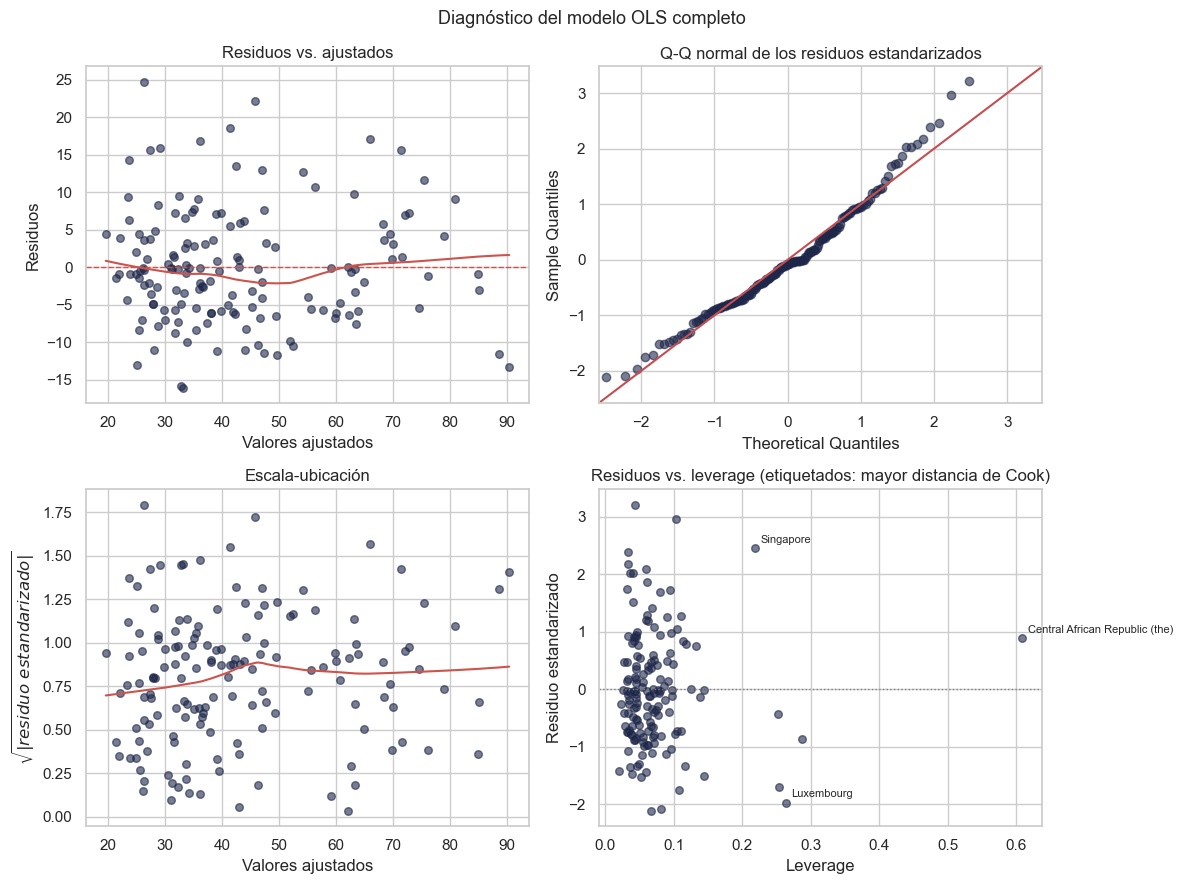

In [14]:
infl = OLSInfluence(ols)
ajustados = ols.fittedvalues
resid_std = infl.resid_studentized_internal
leverage = infl.hat_matrix_diag
cook = infl.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.scatter(ajustados, ols.resid, s=30, alpha=0.6, color=PALETA[4])
ax.axhline(0, color=PALETA[2], ls="--", lw=1)
sns.regplot(x=ajustados, y=ols.resid, lowess=True, scatter=False,
            line_kws={"color": PALETA[2], "lw": 1.5}, ax=ax)
ax.set_xlabel("Valores ajustados"); ax.set_ylabel("Residuos")
ax.set_title("Residuos vs. ajustados")

ax = axes[0, 1]
sm.qqplot(resid_std, line="45", ax=ax, markerfacecolor=PALETA[4],
          markeredgecolor=PALETA[4], alpha=0.6)
ax.set_title("Q-Q normal de los residuos estandarizados")

ax = axes[1, 0]
ax.scatter(ajustados, np.sqrt(np.abs(resid_std)), s=30, alpha=0.6, color=PALETA[4])
sns.regplot(x=ajustados, y=np.sqrt(np.abs(resid_std)), lowess=True, scatter=False,
            line_kws={"color": PALETA[2], "lw": 1.5}, ax=ax)
ax.set_xlabel("Valores ajustados"); ax.set_ylabel(r"$\sqrt{|residuo\ estandarizado|}$")
ax.set_title("Escala-ubicación")

ax = axes[1, 1]
ax.scatter(leverage, resid_std, s=30, alpha=0.6, color=PALETA[4])
ax.axhline(0, color="gray", ls=":", lw=1)
for i in np.argsort(cook)[-3:]:
    ax.annotate(datos.loc[i, "cname"], (leverage[i], resid_std[i]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Leverage"); ax.set_ylabel("Residuo estandarizado")
ax.set_title("Residuos vs. leverage (etiquetados: mayor distancia de Cook)")

fig.suptitle("Diagnóstico del modelo OLS completo", fontsize=13)
plt.tight_layout()
plt.show()

Los supuestos se sostienen razonablemente: no hay embudo, la Q-Q sigue la diagonal salvo
en las colas, y ningún caso tiene distancia de Cook alarmante.

Esto importa porque descarta la explicación fácil. El problema de los coeficientes
absurdos **no** es un outlier ni una violación de supuestos: es la estructura de
correlación entre los predictores.

## La respuesta manual: sacar variables

La solución más simple a la colinealidad es eliminar las variables redundantes y volver a
estimar. Con criterio sustantivo, no automático:

- De los tres índices de V-Dem conservamos **`vdem_libdem`**, que es el más abarcativo:
  incorpora el componente electoral de `polyarchy` y le agrega restricciones al ejecutivo e
  igualdad ante la ley.
- Del bloque de desarrollo conservamos **`undp_hdi`** y sacamos `wdi_lifexp` (que es uno
  de sus componentes) y `wdi_internet`.

In [15]:
P8 = [p for p in PREDICTORES if p not in ("vdem_polyarchy", "vdem_partipdem")]
P6 = [p for p in P8 if p not in ("wdi_lifexp", "wdi_internet")]

def resumen(pred, nombre):
    m = sm.OLS(y, sm.add_constant(datos[pred])).fit()
    vif = calcular_vif(datos[pred])
    return {
        "modelo": nombre,
        "k": len(pred),
        "R2": round(m.rsquared, 4),
        "R2_ajustado": round(m.rsquared_adj, 4),
        "error_residual": round(np.sqrt(m.mse_resid), 2),
        "VIF_maximo": round(vif.max(), 1),
        "signif_5pct": int((m.pvalues.drop("const") < 0.05).sum()),
        "AIC": round(m.aic, 1),
    }

comparacion = pd.DataFrame([
    resumen(PREDICTORES, "Completo (10)"),
    resumen(P8, "Sin las 2 V-Dem (8)"),
    resumen(P6, "Sin V-Dem ni lifexp/internet (6)"),
])
comparacion

,modelo,k,R2,R2_ajustado,error_residual,VIF_maximo,signif_5pct,AIC
0,Completo (10),10,0.8260,0.8137,7.87,40.9,4,1069.2
1,Sin las 2 V-Dem (8),8,0.8043,0.7933,8.29,12.1,2,1083.1
2,Sin V-Dem ni lifexp/internet (6),6,0.8027,0.7946,8.27,4.5,3,1080.3


In [16]:
ols6 = sm.OLS(y, sm.add_constant(datos[P6])).fit()
pd.DataFrame({
    "coeficiente": ols6.params,
    "error_est": ols6.bse,
    "t": ols6.tvalues,
    "p_valor": ols6.pvalues,
}).round(4)

,coeficiente,error_est,t,p_valor
const,4.2889,6.0423,0.7098,0.4790
vdem_libdem,20.6740,5.4360,3.8032,0.0002
undp_hdi,25.6951,8.1834,3.1399,0.0020
wdi_gdpcapcon2015,0.0003,0.0001,6.1398,0.0000
rsf_pfi,0.1157,0.0762,1.5184,0.1311
ef_ef,0.7573,0.4607,1.6439,0.1024
wdi_popurb,-0.0446,0.0467,-0.9542,0.3416


In [17]:
print("VIF del modelo reducido:")
print(calcular_vif(datos[P6]).round(2).to_string())

VIF del modelo reducido:
vdem_libdem          4.50
undp_hdi             3.60
rsf_pfi              3.43
wdi_gdpcapcon2015    2.89
ef_ef                2.87
wdi_popurb           2.18


El diagnóstico mejora de forma contundente. El VIF máximo pasa de **40.9 a 4.5**: ya no
queda ninguna variable por encima de 5. Y los coeficientes recuperan sentido:

- `vdem_libdem` = **+20.7** (p = 0.0002). Positivo, de magnitud plausible.
- `undp_hdi` = **+25.7** (p = 0.002). Ahora sí significativo.
- `wdi_gdpcapcon2015` = +0.0003 (p < 0.001).

Desaparecieron los coeficientes de tres cifras y los signos invertidos.

### Pero la eliminación manual tiene un costo

Comparemos formalmente los dos modelos con un **test F anidado**. La hipótesis nula es que
los cuatro predictores que saqué no aportan nada al ajuste.

In [18]:
ols_completo = sm.OLS(y, sm.add_constant(datos[PREDICTORES])).fit()
F, p_valor, gl = ols_completo.compare_f_test(ols6)
print(f"Test F anidado (completo de 10 vs. reducido de 6)")
print(f"  F = {F:.3f}   gl = {int(gl)}   p = {p_valor:.5f}")

Test F anidado (completo de 10 vs. reducido de 6)
  F = 4.710   gl = 4   p = 0.00135


**p = 0.0013.** Se rechaza la nula: las cuatro variables que saqué **sí** mejoran el
ajuste de forma estadísticamente significativa. Y los criterios de información coinciden:
el AIC empeora de 1069.2 a 1080.3, y el $R^2$ ajustado —que ya penaliza por cantidad de
parámetros— baja de 0.814 a 0.795.

O sea: la eliminación manual **compró interpretabilidad pagando con información**. Los
tres índices de V-Dem no son redundantes al 100%; cada uno aporta un pedacito propio, y al
quedarme con uno tiré esos pedacitos.

Este es el dilema concreto: coeficientes interpretables con menos ajuste, o mejor ajuste
con coeficientes que no se pueden leer. La regularización existe para no tener que elegir
de forma tan binaria.

> **Una advertencia sobre el procedimiento.** Acá saqué cuatro variables por criterio
> sustantivo —miden componentes de las que quedaron— y lo documenté antes de mirar los
> p-valores resultantes. Eso es distinto de **ir eliminando variables de a una según el
> p-valor hasta que todo quede significativo** (*stepwise*). Esa segunda práctica
> invalida los p-valores que sobreviven, porque no contabiliza las decenas de decisiones
> tomadas para llegar ahí: los tests reportados suponen una única especificación elegida
> de antemano. Es una de las formas más comunes y menos visibles de inflar la
> significancia.

## Modelo 2: la respuesta penalizada

> **La idea común.** Ridge y Lasso parten de la misma ecuación lineal pero cambian la
> función objetivo: en vez de minimizar solo la suma de residuos al cuadrado (RSS),
> minimizan RSS **más un término de penalización** sobre el tamaño de los coeficientes. El
> parámetro $\lambda \geq 0$ regula cuánta penalización se aplica. Con $\lambda = 0$ se
> recupera exactamente OLS; a medida que $\lambda$ crece, los coeficientes se contraen
> hacia cero.

### Ridge — penalización L2

$$ \min_{\beta} \; \underbrace{\|y - X\beta\|^2}_{\text{ajuste}} \; + \; \lambda \sum_{j=1}^{k} \beta_j^2 $$

Como la penalización crece con el **cuadrado**, concentrar magnitud en un coeficiente
cuesta más que repartirla: dos coeficientes de 5 penalizan $25 + 25 = 50$, uno solo de 10
penaliza $100$.

Por eso, entre soluciones que ajustan parecido, Ridge prefiere la que **reparte el peso**
entre predictores correlacionados antes que la que se lo asigna a uno solo. Ese reparto es
lo que estabiliza los coeficientes frente a la colinealidad — y es exactamente el remedio
para el par $-49 / +77$ que vimos.

Ningún coeficiente llega a cero exacto: la derivada de $\beta^2$ se anula en el origen y
no empuja hacia él.

### Lasso — penalización L1

$$ \min_{\beta} \; \|y - X\beta\|^2 \; + \; \lambda \sum_{j=1}^{k} |\beta_j| $$

El valor absoluto tiene un **pico** en cero y su derivada no se anula ahí, así que la
solución óptima cae exactamente en cero para las variables que aportan poco. Lasso hace
**selección de variables**; Ridge no.

La forma geométrica de verlo: los problemas anteriores son equivalentes a minimizar el RSS
sujeto a que los coeficientes queden dentro de una región. Para Lasso esa región es un
rombo (en general, un politopo con **vértices sobre los ejes**); para Ridge es un círculo
(una esfera). Las curvas de nivel del RSS son elipses centradas en la solución OLS, y la
solución penalizada es el punto donde la elipse más chica toca la región. Contra un rombo,
ese contacto tiende a ocurrir **en un vértice**, y un vértice tiene coordenadas nulas.
Contra un círculo no hay vértices que tocar.

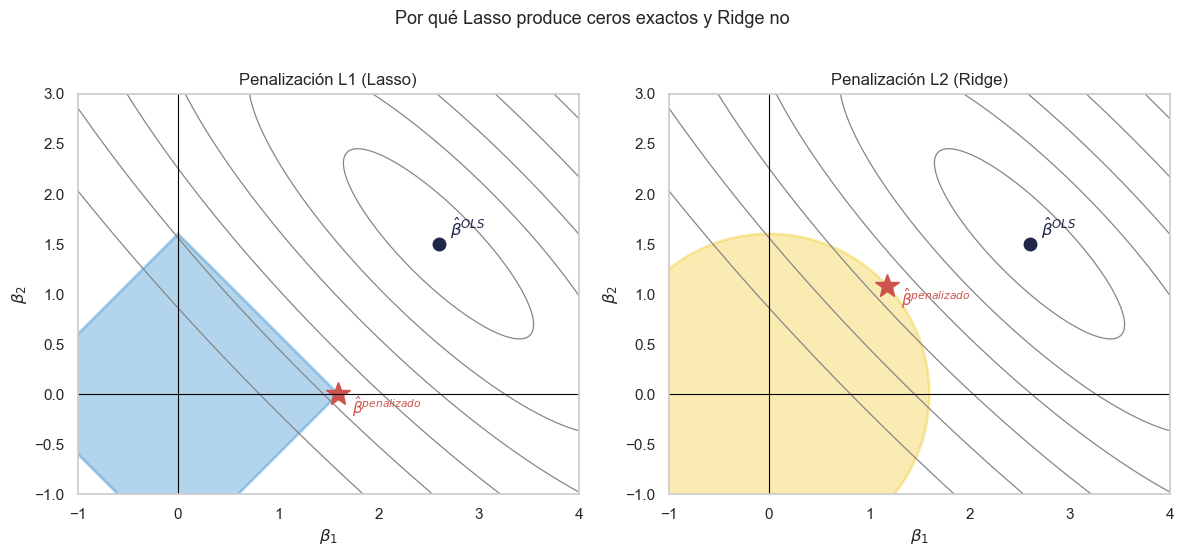

In [19]:
# Geometría de las dos penalizaciones
beta_ols = np.array([2.6, 1.5])          # solución OLS de un problema de 2 coeficientes
A_forma = np.array([[1.0, 0.85], [0.85, 1.0]])   # curvatura del RSS (predictores correlacionados)

g = np.linspace(-1.0, 4.0, 400)
B1, B2 = np.meshgrid(g, g)
D1, D2 = B1 - beta_ols[0], B2 - beta_ols[1]
RSS = A_forma[0, 0]*D1**2 + 2*A_forma[0, 1]*D1*D2 + A_forma[1, 1]*D2**2

t = 1.6
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))

for ax, tipo in zip(axes, ["L1 (Lasso)", "L2 (Ridge)"]):
    ax.contour(B1, B2, RSS, levels=[0.25, 1, 2.2, 4, 6.5, 10], colors=PALETA[3], linewidths=0.9)
    if tipo.startswith("L1"):
        region = plt.Polygon([[t, 0], [0, t], [-t, 0], [0, -t]],
                             facecolor=PALETA[0], alpha=0.30, edgecolor=PALETA[0], lw=2)
        # el óptimo restringido: sobre el vértice del eje beta_1
        opt = np.array([t, 0.0])
    else:
        region = plt.Circle((0, 0), t, facecolor=PALETA[1], alpha=0.30,
                            edgecolor=PALETA[1], lw=2)
        # el óptimo restringido para L2: proyección en la dirección de la elipse
        ang = np.linspace(0, 2*np.pi, 2000)
        px, py = t*np.cos(ang), t*np.sin(ang)
        d1, d2 = px - beta_ols[0], py - beta_ols[1]
        r = A_forma[0, 0]*d1**2 + 2*A_forma[0, 1]*d1*d2 + A_forma[1, 1]*d2**2
        k = r.argmin(); opt = np.array([px[k], py[k]])
    ax.add_patch(region)
    ax.plot(*beta_ols, "o", color=PALETA[4], ms=9)
    ax.annotate(r"$\hat\beta^{OLS}$", beta_ols, xytext=(8, 6),
                textcoords="offset points", fontsize=12, color=PALETA[4])
    ax.plot(*opt, "*", color=PALETA[2], ms=18)
    ax.annotate(r"$\hat\beta^{penalizado}$", opt, xytext=(10, -14),
                textcoords="offset points", fontsize=11, color=PALETA[2])
    ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(-1.0, 4.0); ax.set_ylim(-1.0, 3.0)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
    ax.set_title(f"Penalización {tipo}")
    ax.grid(False)

fig.suptitle("Por qué Lasso produce ceros exactos y Ridge no", fontsize=13)
plt.tight_layout()
plt.show()

En el panel izquierdo la elipse toca el rombo justo en el vértice del eje horizontal:
$\beta_2 = 0$ exactamente, la variable quedó fuera del modelo. En el derecho toca el
círculo en un punto donde **ninguna** de las dos coordenadas es cero: los dos coeficientes
se encogieron, ninguno desapareció.

### Elastic Net — las dos penalizaciones juntas

$$ \min_{\beta} \; \|y - X\beta\|^2 \; + \; \lambda \left( \rho \sum_j |\beta_j| \; + \; \frac{1-\rho}{2} \sum_j \beta_j^2 \right) $$

El parámetro $\rho$ (`l1_ratio` en scikit-learn) mezcla: con $\rho = 1$ es Lasso puro, con
$\rho = 0$ es Ridge puro. Sirve cuando hay **grupos** de variables correlacionadas y se
quiere seleccionar el grupo entero en lugar de un representante arbitrario: Lasso solo
elegiría una de las tres V-Dem, casi al azar entre ellas; Elastic Net puede quedarse con
las tres repartiendo el peso.

### El costo, y por qué se acepta

Los coeficientes de Ridge y Lasso son estimadores **sesgados**: quedan sistemáticamente
menores en magnitud que los de OLS. Se acepta ese sesgo porque viene acompañado de una
reducción mayor de la varianza, y el error cuadrático medio **fuera de la muestra** baja.
Es el compromiso sesgo-varianza que vimos en `9.0`, aplicado a un caso concreto.

OLS es el mejor estimador lineal insesgado. La regularización renuncia deliberadamente a
la insesgadez a cambio de estabilidad.

### Estandarizar no es opcional

La penalización opera sobre la **magnitud** de los coeficientes, y esa magnitud depende de
las unidades de cada variable. `wdi_gdpcapcon2015` está en decenas de miles de dólares y
`vdem_libdem` entre 0 y 1: el coeficiente del PBI tiene que ser diminuto para producir un
efecto comparable, y una penalización que castiga coeficientes grandes lo dejaría
prácticamente intacto mientras aplasta al de V-Dem.

Sin estandarizar, $\lambda$ castiga a las variables de escala chica y perdona a las de
escala grande. En `glmnet` de R esto pasa internamente; en scikit-learn hay que armarlo
explícitamente con un `Pipeline`.

In [20]:
# Qué pasa si NO se estandariza: mismo lambda, coeficientes incomparables
X_crudo = datos[PREDICTORES].values
X_esc = StandardScaler().fit_transform(X_crudo)

sin_esc = Ridge(alpha=10).fit(X_crudo, y).coef_
con_esc = Ridge(alpha=10).fit(X_esc, y).coef_

pd.DataFrame({
    "escala_original": datos[PREDICTORES].std().round(2).values,
    "coef_sin_estandarizar": sin_esc.round(4),
    "coef_estandarizado": con_esc.round(3),
}, index=PREDICTORES)

,escala_original,coef_sin_estandarizar,coef_estandarizado
vdem_polyarchy,0.26,1.5235,-1.411
vdem_libdem,0.26,3.5937,5.847
vdem_partipdem,0.20,1.3820,0.018
undp_hdi,0.16,0.6559,2.223
wdi_gdpcapcon2015,20754.83,0.0004,6.238
rsf_pfi,16.36,0.2958,2.824
ef_ef,2.47,0.5813,1.908
wdi_popurb,21.25,-0.0384,-0.608
wdi_lifexp,8.50,0.3083,1.444
wdi_internet,26.56,0.0879,0.843


Sin estandarizar, el coeficiente del PBI per cápita es 0.0003 y el de `vdem_libdem` es
varios órdenes de magnitud mayor. La penalización $\sum \beta_j^2$ ni registra al primero:
lo que castiga es la unidad de medida, no la importancia. De acá en adelante, todo va
dentro de un `Pipeline` que estandariza primero.

## Elegir $\lambda$ por validación cruzada

$\lambda$ no se conoce de antemano: es un **hiperparámetro**. Se elige por validación
cruzada, el procedimiento de `9.0`: partimos los datos en 10 pliegues, ajustamos 10 veces
dejando afuera un pliegue distinto, y medimos el error sobre la parte que el modelo no vio.

Dos criterios habituales:

- **`lambda.min`**: el $\lambda$ de menor error de validación.
- **`lambda.1se`**: el $\lambda$ **más grande** cuyo error queda dentro de un error
  estándar del mínimo. Es más conservador —penaliza más, modelo más simple— y se apoya en
  que la curva de CV es en sí misma una estimación con ruido: si dos $\lambda$ son
  indistinguibles dentro del margen de error, conviene el que regulariza más.

`glmnet` de R devuelve los dos. En scikit-learn hay que construir el segundo a mano.

In [21]:
CV = KFold(n_splits=10, shuffle=True, random_state=SEED)
alphas = np.logspace(-3, 4, 200)

def curva_cv(estimador_fn, alphas, X_df, y_s, cv):
    # MSE medio y error estándar del MSE para cada alpha
    medias, errores = [], []
    for a in alphas:
        s = cross_val_score(make_pipeline(StandardScaler(), estimador_fn(a)),
                            X_df, y_s, cv=cv, scoring="neg_mean_squared_error")
        medias.append(-s.mean())
        errores.append(s.std(ddof=1) / np.sqrt(len(s)))
    return np.array(medias), np.array(errores)

def lambdas_referencia(alphas, medias, errores):
    i = medias.argmin()
    umbral = medias[i] + errores[i]
    candidatos = np.where(medias <= umbral)[0]
    return alphas[i], alphas[candidatos.max()]

mse_ridge, se_ridge = curva_cv(lambda a: Ridge(alpha=a), alphas, datos[PREDICTORES], y, CV)
lam_min_r, lam_1se_r = lambdas_referencia(alphas, mse_ridge, se_ridge)
print(f"Ridge:  lambda.min = {lam_min_r:8.3f}    lambda.1se = {lam_1se_r:8.2f}")

Ridge:  lambda.min =    0.341    lambda.1se =    77.53


In [22]:
mse_lasso, se_lasso = curva_cv(lambda a: Lasso(alpha=a, max_iter=50000),
                               alphas[alphas <= 100], datos[PREDICTORES], y, CV)
lam_min_l, lam_1se_l = lambdas_referencia(alphas[alphas <= 100], mse_lasso, se_lasso)
print(f"Lasso:  lambda.min = {lam_min_l:8.3f}    lambda.1se = {lam_1se_l:8.2f}")

Lasso:  lambda.min =    0.042    lambda.1se =     1.87


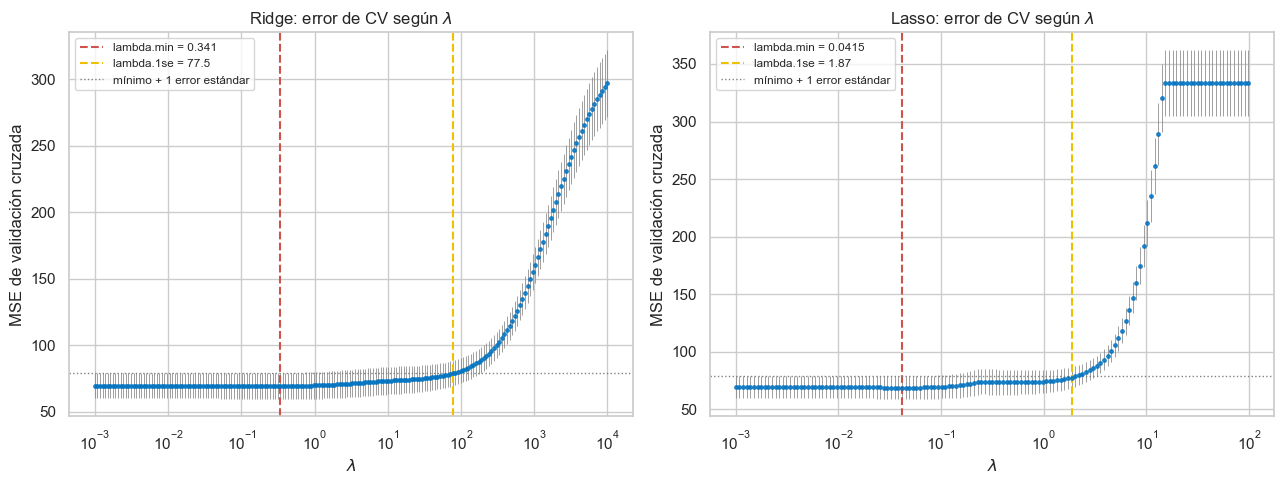

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nombre, al, m, e, lmin, l1se) in zip(axes, [
    ("Ridge", alphas, mse_ridge, se_ridge, lam_min_r, lam_1se_r),
    ("Lasso", alphas[alphas <= 100], mse_lasso, se_lasso, lam_min_l, lam_1se_l),
]):
    ax.errorbar(al, m, yerr=e, fmt="o", ms=2.5, lw=0.7, color=PALETA[0],
                ecolor=PALETA[3], elinewidth=0.7, capsize=0, alpha=0.8)
    ax.axvline(lmin, color=PALETA[2], ls="--", lw=1.5, label=f"lambda.min = {lmin:.3g}")
    ax.axvline(l1se, color=PALETA[1], ls="--", lw=1.5, label=f"lambda.1se = {l1se:.3g}")
    i = m.argmin()
    ax.axhline(m[i] + e[i], color="gray", ls=":", lw=1,
               label="mínimo + 1 error estándar")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("MSE de validación cruzada")
    ax.set_title(f"{nombre}: error de CV según $\\lambda$")
    ax.legend(fontsize=8.5, loc="upper left")

plt.tight_layout()
plt.show()

Las dos curvas tienen la misma forma: planas a la izquierda (penalización despreciable, el
modelo es prácticamente OLS), un mínimo suave, y una subida a la derecha cuando la
penalización empieza a destruir señal.

Fijate en lo plano que es el tramo izquierdo de Ridge. Entre $\lambda = 0.34$ y
$\lambda = 71$ el error de validación apenas se distingue — y esos dos valores producen
coeficientes completamente distintos. Ahí está la clave de lo que viene.

## Trayectoria de los coeficientes

Cada línea es un predictor. A la izquierda la penalización es despreciable y los
coeficientes coinciden con los de OLS; hacia la derecha $\lambda$ crece y los contrae. En
Lasso las líneas **tocan el cero y se quedan ahí**; en Ridge se acercan sin llegar.

Es la visualización central de este notebook: muestra de un vistazo qué hace la
regularización.

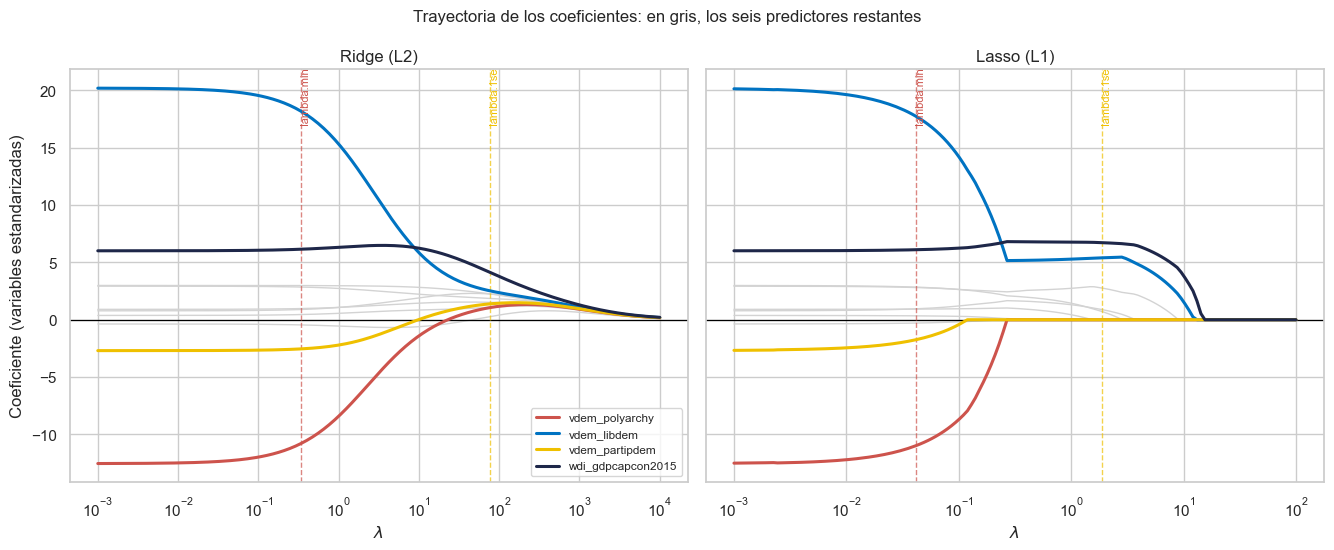

In [24]:
X_esc_df = pd.DataFrame(StandardScaler().fit_transform(datos[PREDICTORES]),
                        columns=PREDICTORES)

path_ridge = np.array([Ridge(alpha=a).fit(X_esc_df, y).coef_ for a in alphas])
al_lasso = alphas[alphas <= 100]
path_lasso = np.array([Lasso(alpha=a, max_iter=50000).fit(X_esc_df, y).coef_
                       for a in al_lasso])

destacadas = {"vdem_polyarchy": PALETA[2], "vdem_libdem": PALETA[0],
              "vdem_partipdem": PALETA[1], "wdi_gdpcapcon2015": PALETA[4]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharey=True)

for ax, (nombre, al, path, lmin, l1se) in zip(axes, [
    ("Ridge (L2)", alphas, path_ridge, lam_min_r, lam_1se_r),
    ("Lasso (L1)", al_lasso, path_lasso, lam_min_l, lam_1se_l),
]):
    for j, v in enumerate(PREDICTORES):
        if v in destacadas:
            ax.plot(al, path[:, j], lw=2.2, color=destacadas[v], label=v, zorder=3)
        else:
            ax.plot(al, path[:, j], lw=1, color="lightgray", zorder=1)
    ax.axhline(0, color="black", lw=0.9)
    ax.axvline(lmin, color=PALETA[2], ls="--", lw=1, alpha=0.7)
    ax.axvline(l1se, color=PALETA[1], ls="--", lw=1, alpha=0.7)
    ax.text(lmin, 22, "  lambda.min", fontsize=8, color=PALETA[2], rotation=90, va="top")
    ax.text(l1se, 22, "  lambda.1se", fontsize=8, color=PALETA[1], rotation=90, va="top")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$")
    ax.set_title(nombre)

axes[0].set_ylabel("Coeficiente (variables estandarizadas)")
axes[0].legend(fontsize=8.5, loc="lower right")
fig.suptitle("Trayectoria de los coeficientes: en gris, los seis predictores restantes",
             fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
# Dónde exactamente Ridge deja de darle signo negativo a vdem_polyarchy
j = PREDICTORES.index("vdem_polyarchy")
positivos = np.where(path_ridge[:, j] > 0)[0]
print(f"Ridge: el coeficiente de vdem_polyarchy pasa a positivo en lambda = {alphas[positivos[0]]:.1f}")

# Cuántas variables conserva Lasso según lambda
for a in [0.04, 0.2, 0.5, 1.0, 2.0, 5.0]:
    c = Lasso(alpha=a, max_iter=50000).fit(X_esc_df, y).coef_
    fuera = [v for v, ci in zip(PREDICTORES, c) if ci == 0]
    print(f"  Lasso lambda={a:5.2f}: conserva {int((c != 0).sum()):2d}/10  "
          f"| descarta: {', '.join(fuera) if fuera else '(nada)'}")

Ridge: el coeficiente de vdem_polyarchy pasa a positivo en lambda = 23.0
  Lasso lambda= 0.04: conserva 10/10  | descarta: (nada)
  Lasso lambda= 0.20: conserva  9/10  | descarta: vdem_partipdem
  Lasso lambda= 0.50: conserva  6/10  | descarta: vdem_polyarchy, vdem_partipdem, wdi_popurb, wdi_internet
  Lasso lambda= 1.00: conserva  6/10  | descarta: vdem_polyarchy, vdem_partipdem, wdi_popurb, wdi_internet
  Lasso lambda= 2.00: conserva  5/10  | descarta: vdem_polyarchy, vdem_partipdem, wdi_popurb, wdi_lifexp, wdi_internet
  Lasso lambda= 5.00: conserva  3/10  | descarta: vdem_polyarchy, vdem_partipdem, rsf_pfi, ef_ef, wdi_popurb, wdi_lifexp, wdi_internet


Los dos mecanismos, en acción sobre nuestro problema:

**Ridge** arranca en $-11.6$ para `vdem_polyarchy` (el disparate de OLS, en unidades
estandarizadas) y lo va empujando hacia arriba hasta que **en $\lambda = 23$ cambia de
signo**. A partir de ahí los tres índices de V-Dem son positivos y de magnitud parecida:
Ridge repartió entre los tres el efecto que OLS había partido en $-49$ y $+77$.

**Lasso** hace otra cosa. En $\lambda = 0.2$ descarta `vdem_partipdem`; en $\lambda = 0.5$
descarta también `vdem_polyarchy` y se queda con `vdem_libdem` como **único representante
del bloque**. Es el comportamiento típico frente a variables correlacionadas: elige una y
tira el resto. Cuál de las tres elige es hasta cierto punto arbitrario — depende de
detalles de la muestra.

## El $\lambda$ de la predicción no es el $\lambda$ de la interpretación

Acá aparece algo que los manuales suelen pasar por alto. La validación cruzada elige
$\lambda$ para **minimizar el error de predicción**, y nada más. Veamos qué coeficientes
entrega cada criterio.

In [26]:
coef_en = lambda est: pd.Series(est.fit(X_esc_df, y).coef_, index=PREDICTORES)

tabla_lambda = pd.DataFrame({
    "OLS": pd.Series(LinearRegression().fit(X_esc_df, y).coef_, index=PREDICTORES),
    f"Ridge lambda.min ({lam_min_r:.2f})": coef_en(Ridge(alpha=lam_min_r)),
    f"Ridge lambda.1se ({lam_1se_r:.1f})": coef_en(Ridge(alpha=lam_1se_r)),
    f"Lasso lambda=0.5": coef_en(Lasso(alpha=0.5, max_iter=50000)),
}).round(2)
tabla_lambda

,OLS,Ridge lambda.min (0.34),Ridge lambda.1se (77.5),Lasso lambda=0.5
vdem_polyarchy,-12.55,-10.79,1.06,-0.00
vdem_libdem,20.20,18.18,2.51,5.19
vdem_partipdem,-2.70,-2.54,1.39,0.00
undp_hdi,2.93,2.85,1.86,2.59
wdi_gdpcapcon2015,6.01,6.15,4.12,6.79
rsf_pfi,2.99,2.98,2.25,1.88
ef_ef,0.77,0.89,2.24,1.56
wdi_popurb,-0.37,-0.45,0.28,-0.00
wdi_lifexp,0.90,0.97,1.52,0.84
wdi_internet,0.37,0.45,1.09,0.00


In [27]:
filas = []
for nombre, est in [
    ("OLS", LinearRegression()),
    (f"Ridge lambda.min ({lam_min_r:.2f})", Ridge(alpha=lam_min_r)),
    (f"Ridge lambda.1se ({lam_1se_r:.1f})", Ridge(alpha=lam_1se_r)),
    ("Lasso lambda=0.5 (6 vars)", Lasso(alpha=0.5, max_iter=50000)),
]:
    s = cross_val_score(make_pipeline(StandardScaler(), est),
                        datos[PREDICTORES], y, cv=CV, scoring="r2")
    filas.append({"modelo": nombre, "R2_validacion_cruzada": round(s.mean(), 4),
                  "desvio_entre_pliegues": round(s.std(), 4)})
pd.DataFrame(filas)

,modelo,R2_validacion_cruzada,desvio_entre_pliegues
0,OLS,0.7807,0.0722
1,Ridge lambda.min (0.34),0.7807,0.0751
2,Ridge lambda.1se (77.5),0.7451,0.0835
3,Lasso lambda=0.5 (6 vars),0.7638,0.0928


El resultado es incómodo y hay que decirlo con claridad:

**En `lambda.min` la colinealidad sigue intacta.** El coeficiente de `vdem_polyarchy`
sigue en $-10.8$ y el de `vdem_libdem` en $+18.2$. La validación cruzada eligió
prácticamente no penalizar, y tiene razón *desde su propio criterio*: para **predecir**, el
par de coeficientes absurdos funciona bien, porque se cancelan de forma consistente. Al
error de predicción no le molesta que los coeficientes individuales no signifiquen nada.

**En `lambda.1se` los coeficientes se vuelven legibles.** Los tres índices de V-Dem quedan
en $+1.06$, $+2.51$ y $+1.39$: todos positivos, magnitudes comparables, lectura sustantiva
directa —la democracia se asocia con menos corrupción y los tres índices apuntan en la
misma dirección—. El costo es real: el $R^2$ de validación baja de **0.781 a 0.745**, unos
3.6 puntos.

La conclusión metodológica: **si el objetivo es predecir, la colinealidad no es tu
problema** y `lambda.min` está bien. Si el objetivo es interpretar coeficientes, hace falta
penalizar más de lo que la CV pediría, y esa decisión se justifica por interpretabilidad,
no por error de predicción. Son dos usos distintos de la misma herramienta y conviene decir
en voz alta cuál se está haciendo.

## Los modelos lado a lado

In [28]:
elastic = ElasticNetCV(alphas=alphas[alphas <= 100],
                       l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                       cv=CV, random_state=SEED, max_iter=50000)
pipe_en = make_pipeline(StandardScaler(), elastic).fit(datos[PREDICTORES], y)
print(f"Elastic Net elegido por CV:  alpha = {elastic.alpha_:.4f}   l1_ratio = {elastic.l1_ratio_}")

Elastic Net elegido por CV:  alpha = 0.0415   l1_ratio = 1.0


In [29]:
# Coeficientes en escala estandarizada; el modelo reducido se muestra sobre sus 6 variables
coef_reducido = pd.Series(
    LinearRegression().fit(X_esc_df[P6], y).coef_, index=P6
).reindex(PREDICTORES)

resumen_coef = pd.DataFrame({
    "OLS (10)": pd.Series(LinearRegression().fit(X_esc_df, y).coef_, index=PREDICTORES),
    "OLS reducido (6)": coef_reducido,
    "Ridge lambda.1se": coef_en(Ridge(alpha=lam_1se_r)),
    "Lasso lambda=0.5": coef_en(Lasso(alpha=0.5, max_iter=50000)),
    "Elastic Net (CV)": pd.Series(elastic.coef_, index=PREDICTORES),
}).round(2)
resumen_coef

,OLS (10),OLS reducido (6),Ridge lambda.1se,Lasso lambda=0.5,Elastic Net (CV)
vdem_polyarchy,-12.55,NaN,1.06,-0.00,-10.98
vdem_libdem,20.20,5.41,2.51,5.19,17.74
vdem_partipdem,-2.70,NaN,1.39,0.00,-1.74
undp_hdi,2.93,3.99,1.86,2.59,2.81
wdi_gdpcapcon2015,6.01,7.00,4.12,6.79,6.10
rsf_pfi,2.99,1.89,2.25,1.88,2.84
ef_ef,0.77,1.87,2.24,1.56,0.95
wdi_popurb,-0.37,-0.94,0.28,-0.00,-0.29
wdi_lifexp,0.90,NaN,1.52,0.84,0.92
wdi_internet,0.37,NaN,1.09,0.00,0.34


In [30]:
def r2_train(est, pred=PREDICTORES):
    m = make_pipeline(StandardScaler(), est).fit(datos[pred], y)
    return m.score(datos[pred], y)

def r2_cv(est, pred=PREDICTORES):
    s = cross_val_score(make_pipeline(StandardScaler(), est), datos[pred], y,
                        cv=CV, scoring="r2")
    return s.mean(), s.std()

filas = []
for nombre, est, pred in [
    ("OLS (10 vars)", LinearRegression(), PREDICTORES),
    ("OLS reducido (6 vars)", LinearRegression(), P6),
    ("Ridge lambda.min", Ridge(alpha=lam_min_r), PREDICTORES),
    ("Ridge lambda.1se", Ridge(alpha=lam_1se_r), PREDICTORES),
    ("Lasso lambda=0.5", Lasso(alpha=0.5, max_iter=50000), PREDICTORES),
    ("Elastic Net (CV)", ElasticNet(alpha=elastic.alpha_, l1_ratio=elastic.l1_ratio_,
                                    max_iter=50000), PREDICTORES),
]:
    m, s = r2_cv(est, pred)
    filas.append({"modelo": nombre,
                  "R2_entrenamiento": round(r2_train(est, pred), 4),
                  "R2_validacion_cruzada": round(m, 4),
                  "desvio": round(s, 4)})
pd.DataFrame(filas)

,modelo,R2_entrenamiento,R2_validacion_cruzada,desvio
0,OLS (10 vars),0.8260,0.7807,0.0722
1,OLS reducido (6 vars),0.8027,0.7621,0.1052
2,Ridge lambda.min,0.8256,0.7807,0.0751
3,Ridge lambda.1se,0.7788,0.7451,0.0835
4,Lasso lambda=0.5,0.8013,0.7638,0.0928
5,Elastic Net (CV),0.8254,0.7829,0.0749


El $R^2$ de entrenamiento se calcula sobre los mismos datos que ajustaron el modelo, así
que es optimista, y **OLS gana ahí por construcción**: es exactamente la cantidad que
minimiza. Cualquier modelo penalizado tiene que quedar peor en esa columna, por
definición. La columna comparable es la de validación cruzada.

Y ahí, con $n = 152$ y $p = 10$, los cinco modelos empatan dentro del margen de error. Lo
cual es la lección honesta: **cuando hay muchas más observaciones que variables, la
regularización aporta poco a la predicción.** Su valor acá es otro —hacer legibles los
coeficientes— y lo pagamos con 3 puntos de $R^2$.

Para ver la regularización haciendo lo que realmente sabe hacer, hay que cambiar el
escenario.

## Cuando $p$ se acerca a $n$

Hasta acá elegimos diez predictores a mano, guiados por la literatura. Pero QOG tiene 320
columnas. La pregunta realista del analista es otra:

> Tengo 194 países y cientos de indicadores. ¿Cuáles importan?

Con mínimos cuadrados esa pregunta no tiene respuesta. Si $p > n$ la matriz $X'X$ no es
invertible y hay infinitas soluciones que ajustan perfecto. Incluso con $p$ un poco menor
que $n$, OLS interpola el ruido y su capacidad predictiva se derrumba.

Armemos ese escenario: todos los indicadores numéricos con al menos 60% de cobertura,
excluyendo las familias contaminadas por el CPI.

In [31]:
EXCLUIR = ("wbgi_", "icrg_", "ti_")          # familias que usan el CPI como insumo
IDS = ("ccode", "ccode_qog", "ccodecow")

numericas = qog.select_dtypes(include=[np.number])
muchos = [c for c in numericas.columns
          if not c.startswith(EXCLUIR)
          and c not in IDS
          and numericas[c].notna().mean() >= 0.60]

anchos = qog[["cname"] + muchos + [OBJETIVO]].dropna(subset=[OBJETIVO]).reset_index(drop=True)
X_ancho, y_ancho = anchos[muchos], anchos[OBJETIVO]

print(f"observaciones (n): {len(anchos)}")
print(f"predictores  (p): {len(muchos)}")
print(f"p / n            : {len(muchos) / len(anchos):.2f}")
print(f"\nceldas faltantes en X: {X_ancho.isna().mean().mean():.1%} "
      f"(se imputan por mediana DENTRO de cada pliegue de la CV)")

observaciones (n): 178
predictores  (p): 197
p / n            : 1.11

celdas faltantes en X: 10.1% (se imputan por mediana DENTRO de cada pliegue de la CV)


197 predictores y 178 países: **hay más variables que observaciones**. Y quedan celdas
faltantes, que imputamos por mediana — pero dentro del `Pipeline`, así que la mediana se
calcula con los datos de entrenamiento de cada pliegue y nunca con el pliegue de
validación. Imputar antes de partir sería fuga de información.

In [32]:
CV_ancho = KFold(n_splits=5, shuffle=True, random_state=7)
rejilla = np.logspace(-3, 3, 120)

modelos_anchos = [
    ("OLS", LinearRegression()),
    ("Ridge", RidgeCV(alphas=rejilla, cv=CV_ancho)),
    ("Lasso", LassoCV(alphas=rejilla, cv=CV_ancho, random_state=7, max_iter=50000)),
    ("Elastic Net", ElasticNetCV(alphas=rejilla, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                                 cv=CV_ancho, random_state=7, max_iter=50000)),
]

filas, ajustados_anchos = [], {}
for nombre, est in modelos_anchos:
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), est)
    s = cross_val_score(pipe, X_ancho, y_ancho, cv=CV_ancho, scoring="r2")
    pipe.fit(X_ancho, y_ancho)
    ajustados_anchos[nombre] = pipe
    coefs = pipe[-1].coef_
    filas.append({"modelo": nombre,
                  "R2_validacion_cruzada": round(s.mean(), 4),
                  "desvio_entre_pliegues": round(s.std(), 4),
                  "variables_usadas": int((coefs != 0).sum())})

resultados_anchos = pd.DataFrame(filas)
resultados_anchos

,modelo,R2_validacion_cruzada,desvio_entre_pliegues,variables_usadas
0,OLS,0.2147,0.7867,197
1,Ridge,0.8875,0.0179,196
2,Lasso,0.9475,0.0208,22
3,Elastic Net,0.9475,0.0207,22


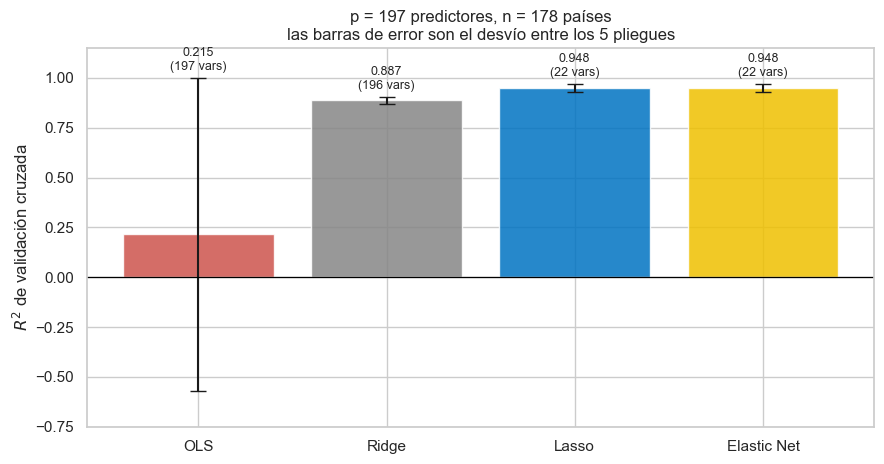

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.8))
r = resultados_anchos
colores = [PALETA[2], PALETA[3], PALETA[0], PALETA[1]]
ax.bar(r["modelo"], r["R2_validacion_cruzada"],
       yerr=r["desvio_entre_pliegues"], capsize=6, color=colores, alpha=0.85)
ax.axhline(0, color="black", lw=0.9)
for i, fila in r.iterrows():
    ax.text(i, max(fila["R2_validacion_cruzada"], 0) + fila["desvio_entre_pliegues"] + 0.04,
            f"{fila['R2_validacion_cruzada']:.3f}\n({fila['variables_usadas']} vars)",
            ha="center", fontsize=9)
ax.set_ylabel("$R^2$ de validación cruzada")
ax.set_ylim(-0.75, 1.15)
ax.set_title(f"p = {len(muchos)} predictores, n = {len(anchos)} países\n"
             "las barras de error son el desvío entre los 5 pliegues")
plt.tight_layout()
plt.show()

El gráfico se explica solo.

**OLS obtiene $R^2 = 0.215$ con un desvío de 0.787 entre pliegues.** El desvío es casi
cuatro veces la media: en algunos pliegues el modelo predice razonablemente y en otros
produce $R^2$ fuertemente negativo, o sea **peor que predecir siempre el promedio**. No es
un modelo malo, es un modelo inutilizable, y el promedio de 0.215 esconde ese caos. Siempre
hay que mirar la dispersión entre pliegues, no solo la media.

**Ridge llega a 0.888 con desvío 0.018.** Cuarenta veces más estable, usando prácticamente
las mismas 197 variables.

**Lasso llega a 0.947 con 22 variables.** El mejor ajuste y el modelo más chico, a la vez.
Descartó casi el 90% de los predictores.

Acá la regularización no es un ajuste fino: es la diferencia entre tener un modelo y no
tenerlo.

In [34]:
lasso_final = ajustados_anchos["Lasso"][-1]
seleccionadas = (pd.Series(lasso_final.coef_, index=muchos)
                 .loc[lambda s: s != 0]
                 .sort_values(key=abs, ascending=False))

print(f"Lasso seleccionó {len(seleccionadas)} de {len(muchos)} predictores "
      f"(alpha = {lasso_final.alpha_:.4f}):\n")
seleccionadas.round(3).to_frame("coeficiente")

Lasso seleccionó 22 de 197 predictores (alpha = 0.4702):



,coeficiente
bci_bci,-9.464
vdem_corr,-3.960
fh_fog,1.825
bti_acp,1.030
wdi_gdpcapcon2015,0.927
wjp_leg_br,0.543
wjp_civ_just,0.478
wjp_crim_jus,0.307
fh_feb,0.300
vdem_delibdem,0.246


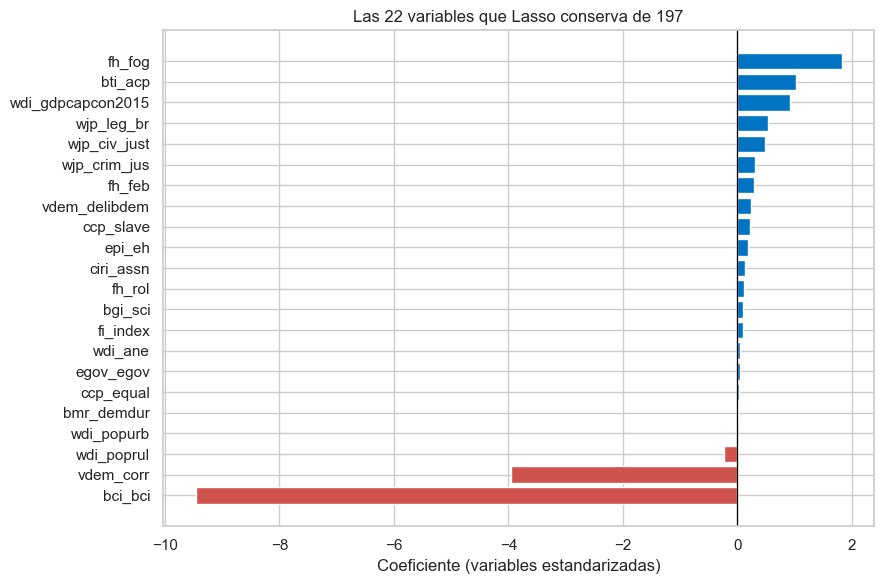

In [35]:
fig, ax = plt.subplots(figsize=(9, 6))
s = seleccionadas.sort_values()
ax.barh(s.index, s.values,
        color=[PALETA[2] if v < 0 else PALETA[0] for v in s.values])
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel("Coeficiente (variables estandarizadas)")
ax.set_title(f"Las {len(s)} variables que Lasso conserva de {len(muchos)}")
plt.tight_layout()
plt.show()

La selección tiene sentido sustantivo, y eso es lo que la vuelve creíble. Lasso —que no
sabe nada de política comparada— se quedó con indicadores de **corrupción medida por otras
vías** (`bci_bci`, `vdem_corr`), de **estado de derecho y calidad judicial**
(`fh_rol`, `wjp_civ_just`, `wjp_crim_jus`, `wjp_leg_br`), de **desarrollo económico**
(`wdi_gdpcapcon2015`) y de **calidad de la democracia** (`vdem_delibdem`, `bti_acp`,
`fh_fog`).

Los dos coeficientes más grandes son **negativos**, y así corresponde: `bci_bci` (Bayesian
Corruption Indicator) y `vdem_corr` miden corrupción en la dirección **opuesta** al CPI
—más alto es peor—, así que una relación inversa con el CPI es exactamente lo esperable. Un
signo positivo ahí habría sido la señal de alarma.

Es, a grandes rasgos, la lista que armaría alguien que conoce la literatura. Con la
diferencia de que salió de los datos, y de que descartó explícitamente 175 indicadores que
no aportaban una vez controlado por estos.

Una advertencia sobre estos coeficientes: son **sesgados** y la selección es **inestable**.
Con otra semilla de partición, Lasso elegiría un conjunto parecido pero no idéntico,
especialmente entre variables correlacionadas. Sirven para responder "¿qué familias de
indicadores importan?", no para afirmar "`wjp_civ_just` tiene un efecto de 1.8".

## Cierre aplicado: los casos que el modelo no explica

Hasta acá el modelo fue el protagonista. Ahora demos vuelta la pregunta.

Un modelo que explica el 78% de la variación deja un 22% sin explicar, y ese residuo no es
solo ruido. La diferencia entre lo que el modelo espera **según la estructura
institucional y económica de un país** y lo que ese país efectivamente puntúa es una señal
sustantiva: dice que ahí está pasando algo que las variables estructurales no capturan.

Ese es el uso que un politólogo le da a una regresión que no es puramente predictiva:
**identificar los casos desviados para estudiarlos en profundidad**. Es el puente entre el
análisis cuantitativo extensivo y el estudio de casos.

Usamos el modelo Ridge en `lambda.1se`, que es el que tiene coeficientes interpretables.

In [36]:
modelo_cierre = make_pipeline(StandardScaler(), Ridge(alpha=lam_1se_r))
modelo_cierre.fit(datos[PREDICTORES], y)

resultados = datos[["cname", OBJETIVO]].copy()
resultados["predicho"] = modelo_cierre.predict(datos[PREDICTORES])
resultados["residuo"] = resultados[OBJETIVO] - resultados["predicho"]
resultados["desvio_abs"] = resultados["residuo"].abs()
resultados["tipo"] = np.where(resultados["residuo"] > 0,
                              "Más transparente de lo esperado",
                              "Menos transparente de lo esperado")

destacados = resultados.nlargest(10, "desvio_abs")
print(f"Desvío absoluto promedio: {resultados['desvio_abs'].mean():.1f} puntos de CPI")
resultados.sort_values("residuo", ascending=False).head(8).round(1)

Desvío absoluto promedio: 6.7 puntos de CPI


,cname,ti_cpi,predicho,residuo,desvio_abs,tipo
118,Rwanda,51.0,26.0,25.0,25.0,Más transparente de lo esperado
12,Bhutan,68.0,45.4,22.6,22.6,Más transparente de lo esperado
123,Singapore,83.0,61.5,21.5,21.5,Más transparente de lo esperado
100,New Zealand,87.0,67.7,19.3,19.3,Más transparente de lo esperado
15,Botswana,60.0,41.4,18.6,18.6,Más transparente de lo esperado
47,Finland,87.0,69.2,17.8,17.8,Más transparente de lo esperado
139,United Arab Emirates (the),67.0,49.2,17.8,17.8,Más transparente de lo esperado
46,Fiji,53.0,37.2,15.8,15.8,Más transparente de lo esperado


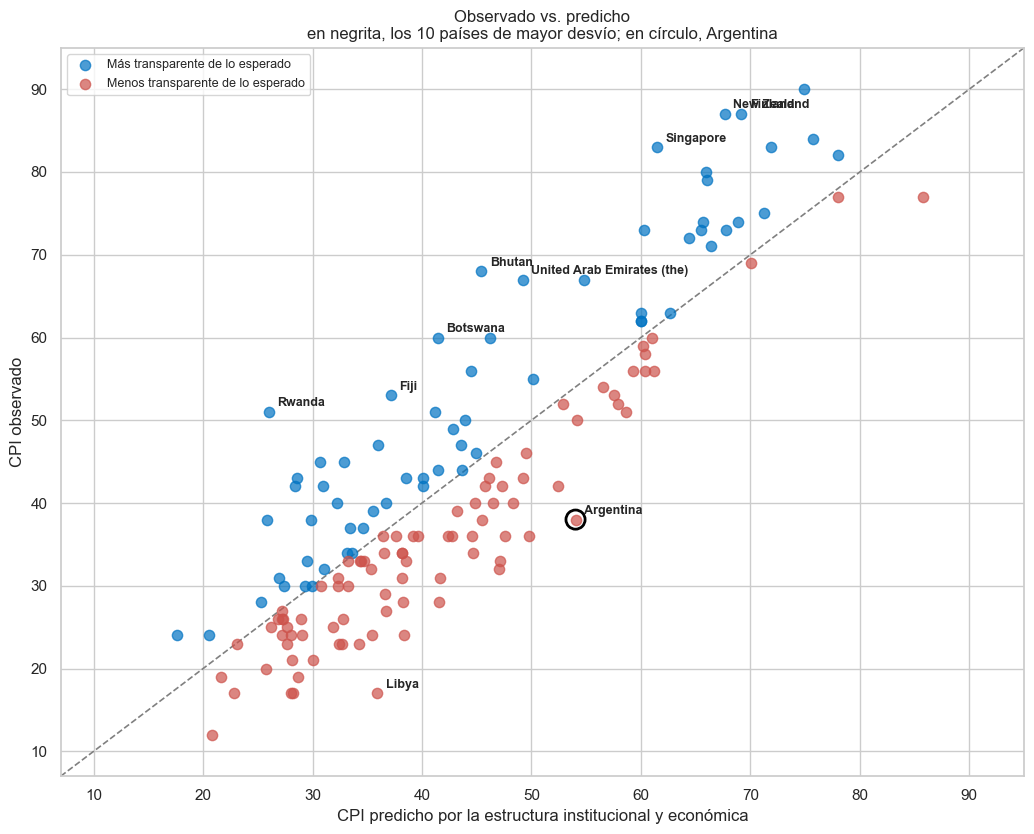

In [37]:
fig, ax = plt.subplots(figsize=(10.5, 8.5))

lim = [resultados[["predicho", OBJETIVO]].min().min() - 5,
       resultados[["predicho", OBJETIVO]].max().max() + 5]
ax.plot(lim, lim, ls="--", color="gray", lw=1.2, zorder=1)

for tipo, color in [("Más transparente de lo esperado", PALETA[0]),
                    ("Menos transparente de lo esperado", PALETA[2])]:
    sub = resultados[resultados["tipo"] == tipo]
    ax.scatter(sub["predicho"], sub[OBJETIVO], s=55, alpha=0.7,
               color=color, label=tipo, zorder=2)

for _, fila in destacados.iterrows():
    ax.annotate(fila["cname"], (fila["predicho"], fila[OBJETIVO]),
                fontsize=9, fontweight="bold", zorder=4,
                xytext=(6, 4), textcoords="offset points")

arg = resultados[resultados["cname"] == "Argentina"].iloc[0]
ax.scatter([arg["predicho"]], [arg[OBJETIVO]], s=190, facecolor="none",
           edgecolor="black", lw=2, zorder=3)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("CPI predicho por la estructura institucional y económica")
ax.set_ylabel("CPI observado")
ax.set_title("Observado vs. predicho\nen negrita, los 10 países de mayor desvío; "
             "en círculo, Argentina", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [38]:
extremos = pd.concat([
    resultados.nlargest(6, "residuo").assign(grupo="Mejor de lo esperado"),
    resultados.nsmallest(6, "residuo").assign(grupo="Peor de lo esperado"),
])
extremos[["grupo", "cname", OBJETIVO, "predicho", "residuo"]].round(1).reset_index(drop=True)

,grupo,cname,ti_cpi,predicho,residuo
0,Mejor de lo esperado,Rwanda,51.0,26.0,25.0
1,Mejor de lo esperado,Bhutan,68.0,45.4,22.6
2,Mejor de lo esperado,Singapore,83.0,61.5,21.5
3,Mejor de lo esperado,New Zealand,87.0,67.7,19.3
4,Mejor de lo esperado,Botswana,60.0,41.4,18.6
5,Mejor de lo esperado,Finland,87.0,69.2,17.8
6,Peor de lo esperado,Libya,17.0,35.9,-18.9
7,Peor de lo esperado,Argentina,38.0,54.0,-16.0
8,Peor de lo esperado,Dominican Republic (the),32.0,47.0,-15.0
9,Peor de lo esperado,Lebanon,24.0,38.4,-14.4


### Cómo se lee esto

**Arriba de la diagonal** hay países que puntúan mucho mejor de lo que su estructura
predice. Rwanda es el caso extremo: el modelo le asigna 26 puntos y obtiene **51**, una
brecha de 25. Singapur (+21), Bhután (+23) y Botswana (+19) van en el mismo sentido. El
patrón es reconocible para cualquiera que haya leído literatura sobre desarrollo: son
casos de **capacidad estatal alta con democracia baja o intermedia**, donde el control de
la corrupción se logró por vías que un índice de democracia no registra. Rwanda y Singapur
son los ejemplos canónicos del debate sobre autoritarismos desarrollistas.

**Abajo de la diagonal** están los países que puntúan peor de lo que su estructura
sugiere. Y ahí aparece **Argentina**, con el segundo desvío negativo más grande de la
muestra: el modelo predice un CPI de **54** y el observado es **38**. Una brecha de 16
puntos.

Eso es un resultado sustantivo, no un error. Dice que Argentina tiene el nivel de
democracia liberal, desarrollo humano, PBI per cápita y libertad de prensa de un país que
debería estar cerca de Chile o Uruguay en percepción de corrupción, y no lo está. La
pregunta *"¿qué explica esos 16 puntos?"* no la contesta esta regresión — pero es la
regresión la que la formuló con precisión.

En el modelo: 12 de 12 países buscados
Sin datos completos: []


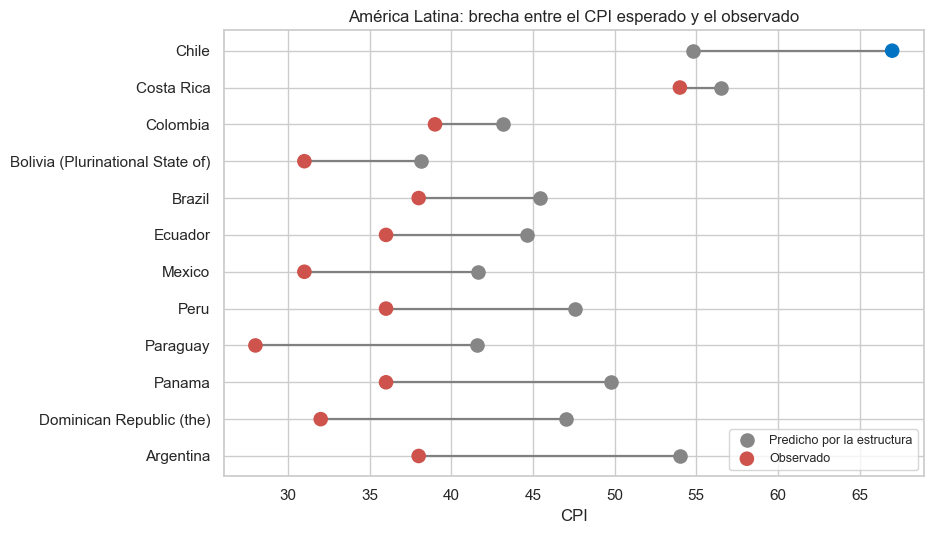

In [39]:
# Nombres tal como aparecen en QOG. Uruguay no está: quedó afuera por ef_ef.
region = ["Argentina", "Brazil", "Chile", "Paraguay", "Bolivia (Plurinational State of)",
          "Peru", "Colombia", "Mexico", "Ecuador", "Costa Rica", "Panama",
          "Dominican Republic (the)"]
comparado = (resultados[resultados["cname"].isin(region)]
             .sort_values("residuo")
             .reset_index(drop=True))
print("En el modelo:", len(comparado), "de", len(region), "países buscados")
print("Sin datos completos:", sorted(set(region) - set(comparado["cname"])))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
posiciones = np.arange(len(comparado))
ax.hlines(posiciones, comparado["predicho"], comparado[OBJETIVO],
          color="gray", lw=1.6, zorder=1)
ax.scatter(comparado["predicho"], posiciones, s=90, color=PALETA[3],
           label="Predicho por la estructura", zorder=2)
ax.scatter(comparado[OBJETIVO], posiciones, s=90,
           color=[PALETA[2] if r < 0 else PALETA[0] for r in comparado["residuo"]],
           label="Observado", zorder=3)
ax.set_yticks(posiciones)
ax.set_yticklabels(comparado["cname"])
ax.set_xlabel("CPI")
ax.set_title("América Latina: brecha entre el CPI esperado y el observado")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### El producto concreto

La tabla de residuos ordenada es un **instrumento de selección de casos**. Si el objetivo
de una investigación es entender qué produce corrupción más allá de los factores
estructurales, los casos a estudiar no son los que tienen más corrupción en términos
absolutos —eso lo explica la pobreza— sino los que **más se desvían de su predicción**.

Para un trabajo sobre Argentina, la tabla siguiente ofrece dos comparaciones defendibles
metodológicamente:

- **Chile**, que es el país con la estructura más parecida a la argentina de toda la muestra
  (0.8 puntos de diferencia en el CPI predicho) y sin embargo puntúa 29 puntos más arriba en
  el observado. La comparación más limpia posible: misma estructura, resultado opuesto.
- **Trinidad y Tobago, Croacia y Chipre**, que comparten con Argentina estructura y signo
  del desvío: qué tienen en común los países que rinden por debajo de lo que su
  institucionalidad promete.

Y si la pregunta es por la magnitud del desvío más que por la estructura, los pares son
**República Dominicana ($-15.0$), Mongolia ($-14.1$) y Panamá ($-13.8$)**.

Ese es el aporte de la regresión regularizada acá: no predice la corrupción argentina
—falla en 16 puntos— sino que **cuantifica cuánto falla y contra qué referencia**, que es
justamente el insumo que necesita el diseño de investigación cualitativa.

In [40]:
candidatos = resultados.copy()
arg_pred = arg["predicho"]
candidatos["distancia_estructural"] = (candidatos["predicho"] - arg_pred).abs()
similares = (candidatos[candidatos["cname"] != "Argentina"]
             .nsmallest(8, "distancia_estructural")
             .sort_values("residuo", ascending=False))

print(f"Argentina: CPI predicho = {arg_pred:.1f}, observado = {arg[OBJETIVO]:.0f}, "
      f"brecha = {arg['residuo']:+.1f}\n")
print("Países con estructura institucional y económica más parecida a la argentina:")
similares[["cname", OBJETIVO, "predicho", "residuo", "distancia_estructural"]].round(1).reset_index(drop=True)

Argentina: CPI predicho = 54.0, observado = 38, brecha = -16.0

Países con estructura institucional y económica más parecida a la argentina:


,cname,ti_cpi,predicho,residuo,distancia_estructural
0,Chile,67.0,54.8,12.2,0.8
1,Poland,55.0,50.1,4.9,3.9
2,Greece,52.0,52.9,-0.9,1.2
3,Costa Rica,54.0,56.5,-2.5,2.5
4,Croatia,50.0,54.1,-4.1,0.1
5,Slovakia,53.0,57.5,-4.5,3.5
6,Cyprus,52.0,57.9,-5.9,3.9
7,Trinidad and Tobago,42.0,52.5,-10.5,1.6


## Síntesis

1. Diez indicadores estructurales explican el **82.6%** de la variación del CPI, pero los
   coeficientes individuales son ilegibles: `vdem_polyarchy` recibe **−49** y
   `vdem_libdem` **+77**, dos variables que correlacionan 0.977. El VIF de las tres V-Dem
   está entre 30 y 41.

2. Sacar variables a mano baja el VIF máximo a 4.5 y devuelve coeficientes sensatos, pero
   el test F ($p = 0.0013$) y el AIC muestran que **se perdió información real**. No es
   gratis.

3. Ridge reparte el peso entre predictores correlacionados; Lasso elige un representante
   del grupo y descarta el resto; Elastic Net interpola entre los dos. La geometría de la
   región factible es lo que produce esa diferencia.

4. **El $\lambda$ óptimo depende del objetivo.** `lambda.min` optimiza predicción y deja la
   colinealidad intacta, porque a la predicción no le molesta. `lambda.1se` vuelve
   legibles los coeficientes —los tres índices V-Dem pasan a $+1.06$, $+2.51$, $+1.39$— a
   cambio de 3.6 puntos de $R^2$.

5. Con $n = 152$ y $p = 10$ la regularización aporta poco a la predicción. Con $p = 197$ y
   $n = 178$ **es la diferencia entre tener modelo y no tenerlo**: OLS entrega
   $R^2 = 0.215 \pm 0.787$ y Lasso $0.947 \pm 0.021$ con 22 variables.

6. Los residuos son un resultado, no un descarte. Argentina puntúa **16 puntos por debajo**
   de lo que su estructura predice, y esa brecha —con Chile de un lado y República
   Dominicana, Mongolia y Panamá del otro— es un diseño de investigación.

7. `dropna()` costó 42 países, y a Uruguay lo dejó afuera **un único dato faltante**. La
   eliminación por lista nunca es neutral.

## Lo que sigue

En `9.2` mantenemos el modelo lineal pero cambiamos la variable a explicar: pasa a ser
**categórica**. Ahí la función de enlace se vuelve logística y estamos en la rama de
**clasificación**. La regularización L1 y L2 que vimos acá reaparece exactamente igual,
así que no habrá que volver a explicarla.